In [1]:
import pandas as pd
import missingno as msno
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def concat_data():
    mechanisms = ['MCAR', 'MAR_l', 'MAR_m', 'MAR_h', 'MNAR_l','MNAR_m', 'MNAR_h']
    data = {}
    for miss in ['05','10','15','20','25']:
        data[miss] = []
        for mech in mechanisms:
            path = f"COVID-19-Wearables-Missing/{mech}/AAXAA7Z/1"
            df = pd.read_csv(os.path.join(path, f"AAXAA7Z_hr_{mech}_1_{miss}.csv"))
            df['mechanism'] = mech
            df['miss'] = miss + '%'
            data[miss].append(df)

    dist = {}
    for miss, dfs in data.items():
        dist[miss] = []
        for df in dfs:
            nan_indices = df[df['heartrate'].isna()].index
            target_values = df.loc[nan_indices, ['target', 'mechanism', 'miss']]
            print(f"Missing: {miss}, Mechanism: {df['mechanism'].iloc[0]}, Missing Values: {len(nan_indices)}")
            dist[miss].append(target_values)
        dist[miss] = pd.concat(dist[miss], ignore_index=True)

    df_all = pd.concat([dist[miss] for miss in dist], ignore_index=True)
    return df_all, dist


df_all, df_miss = concat_data()


Missing: 05, Mechanism: MCAR, Missing Values: 31234
Missing: 05, Mechanism: MAR_l, Missing Values: 31234
Missing: 05, Mechanism: MAR_m, Missing Values: 31234
Missing: 05, Mechanism: MAR_h, Missing Values: 31234
Missing: 05, Mechanism: MNAR_l, Missing Values: 31234
Missing: 05, Mechanism: MNAR_m, Missing Values: 31234
Missing: 05, Mechanism: MNAR_h, Missing Values: 31234
Missing: 10, Mechanism: MCAR, Missing Values: 60906
Missing: 10, Mechanism: MAR_l, Missing Values: 60906
Missing: 10, Mechanism: MAR_m, Missing Values: 60906
Missing: 10, Mechanism: MAR_h, Missing Values: 60906
Missing: 10, Mechanism: MNAR_l, Missing Values: 60906
Missing: 10, Mechanism: MNAR_m, Missing Values: 60906
Missing: 10, Mechanism: MNAR_h, Missing Values: 60906
Missing: 15, Mechanism: MCAR, Missing Values: 89094
Missing: 15, Mechanism: MAR_l, Missing Values: 89094
Missing: 15, Mechanism: MAR_m, Missing Values: 89094
Missing: 15, Mechanism: MAR_h, Missing Values: 89094
Missing: 15, Mechanism: MNAR_l, Missing Val

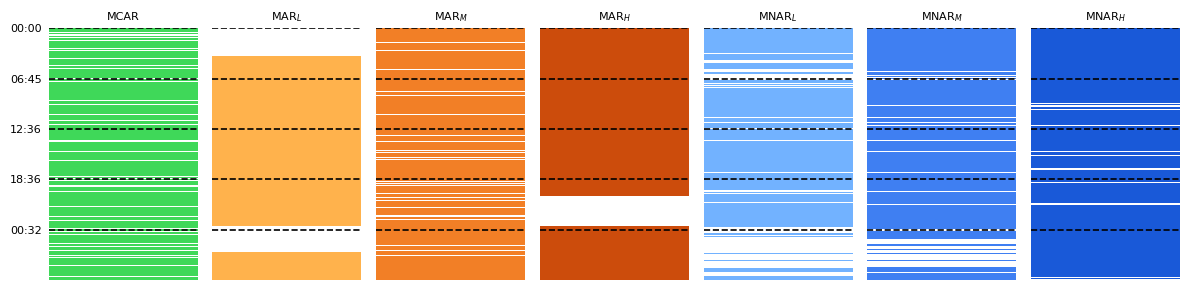

In [6]:
from matplotlib.patches import Patch

df_mec = {}
for mec in ['MCAR','MAR_l', 'MAR_m', 'MAR_h', 'MNAR_l', 'MNAR_m', 'MNAR_h']:
    df_mec[mec] = [pd.read_csv(os.path.join(f'COVID-19-Wearables-Missing/{mec}/AAXAA7Z/1', f)) 
                   for f in sorted(os.listdir(f'COVID-19-Wearables-Missing/{mec}/AAXAA7Z/1')) if f.endswith('.csv')]

color_map = {
    'MCAR':   (0.25, 0.85, 0.35),   # verde vibrante
    'MAR_l':  (1.00, 0.70, 0.30),   # laranja claro
    'MAR_m':  (0.95, 0.50, 0.15),   # laranja médio
    'MAR_h':  (0.80, 0.30, 0.05),   # laranja escuro
    'MNAR_l': (0.45, 0.70, 1.00),   # azul claro
    'MNAR_m': (0.25, 0.50, 0.95),   # azul médio
    'MNAR_h': (0.10, 0.35, 0.85),   # azul escuro
}

N = 13000
D = 5
y_ticks = []
# Select the missing rate you want to visualize, e.g., '15'
missing_rate_idx = ['05', '10', '15', '20', '25'].index('15')

# Visualize only the selected missing rate across mechanisms
fig, axes = plt.subplots(1, len(df_mec), figsize=(12, 3))
for idx, (mec, dfs) in enumerate(df_mec.items()):
    
    df_selected = dfs[missing_rate_idx]
    msno.matrix(df_selected[['heartrate']][:N], sparkline=False, ax=axes[idx], fontsize=7, labels="", color=color_map[mec])
    axes[idx].set_title(mec, fontsize=8)

    if "_" in mec:
        base, sub = mec.split("_")
        mec_label = rf"{base}$_{{{sub.upper()}}}$"
    else:
        mec_label = mec
    axes[idx].set_title(mec_label, fontsize=8)


    if idx == 0:
        axes[idx].get_yaxis().set_visible(True)
        ticks = df_selected.head(N).index[::int(N/D)]
        labels = pd.to_datetime(df_selected["datetime"].head(N).iloc[::int(N/D)]).dt.strftime('%H:%M')
        axes[idx].tick_params(axis='y', pad=5, length=0)
        axes[idx].set_yticks(ticks)
        axes[idx].set_yticklabels(labels, fontsize=8, color='black')
        time_ticks = ticks
    # if idx == 6:
    #     axes[idx].yaxis.tick_right()
    #     axes[idx].yaxis.set_label_position("right")
    #     axes[idx].get_yaxis().set_visible(True)
    #     ticks = df_selected.head(N).index[::int(N/D)]
    #     labels = pd.to_datetime(df_selected["datetime"].head(N).iloc[::int(N/D)]).dt.strftime('%H:%M')
    #     axes[idx].tick_params(axis='y', pad=5, length=0)
    #     axes[idx].set_yticks(ticks)
    #     axes[idx].set_yticklabels(labels, fontsize=8, color='black')
    #     time_ticks = ticks
    else:
        axes[idx].get_yaxis().set_visible(False)

for y in time_ticks:
    for ax in axes:
        ax.axhline(y, color='black', linestyle='--', linewidth=1.2, alpha=1, zorder=10)

# legend_elements = [Patch(facecolor=color_map[key], edgecolor='k', label=key) for key in color_map]
# fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=len(color_map), fontsize=9)
plt.tight_layout()
plt.savefig('Plots/mec_comparison.eps', dpi=600, bbox_inches='tight')
plt.show()


In [2]:
from matplotlib.patches import Patch
import os, pandas as pd, matplotlib.pyplot as plt
import missingno as msno

# === Load data ===
df_mec = {}
for mec in ['MCAR', 'MAR_l', 'MAR_m', 'MAR_h', 'MNAR_l', 'MNAR_m', 'MNAR_h']:
    df_mec[mec] = [
        pd.read_csv(os.path.join(f'COVID-19-Wearables-Missing/{mec}/AAXAA7Z/1', f))
        for f in sorted(os.listdir(f'COVID-19-Wearables-Missing/{mec}/AAXAA7Z/1')) if f.endswith('.csv')
    ]

color_map = {
    'MCAR':   (0.25, 0.85, 0.35),
    'MAR_l':  (1.00, 0.70, 0.30),
    'MAR_m':  (0.95, 0.50, 0.15),
    'MAR_h':  (0.80, 0.30, 0.05),
    'MNAR_l': (0.45, 0.70, 1.00),
    'MNAR_m': (0.25, 0.50, 0.95),
    'MNAR_h': (0.10, 0.35, 0.85),
}

missing_rates = ['05', '10', '15', '20', '25']
N = 13000
D = 5

# === Create grid (7 rows × 5 columns) ===
fig, axes = plt.subplots(len(df_mec), len(missing_rates), figsize=(8, 10))

for i, (mec, dfs) in enumerate(df_mec.items()):
    for j, rate in enumerate(missing_rates):
        df_selected = dfs[j]
        ax = axes[i, j]

        # Draw missingness matrix
        msno.matrix(df_selected[['heartrate']][:N],
                    sparkline=False, ax=ax,
                    fontsize=6, labels="", color=color_map[mec])

        # Column titles: missing rates (top)
        if i == 0:
            ax.set_title(f"{rate}%", fontsize=8)

        # Row labels: mechanisms (left side)
        if j == 0:
            if "_" in mec:
                base, sub = mec.split("_")
                mec_label = rf"{base}$_{{{sub.upper()}}}$"
            else:
                mec_label = mec
            ax.set_ylabel(mec_label, fontsize=10, rotation=90, labelpad=15, va='center')
        else:
            ax.set_ylabel("")

        # Configure Y ticks only for first column
        if j == 0:
            ax.get_yaxis().set_visible(True)
            ticks = df_selected.head(N).index[::int(N / D)]
            labels = pd.to_datetime(df_selected["datetime"].head(N).iloc[::int(N / D)]).dt.strftime('%H:%M')
            ax.tick_params(axis='y', pad=5, length=0)
            ax.set_yticks(ticks)
            ax.set_yticklabels(labels, fontsize=6, color='black')
            time_ticks = ticks
        else:
            ax.get_yaxis().set_visible(False)

# === Add horizontal alignment lines ===
for y in time_ticks:
    for ax_row in axes:
        for ax in ax_row:
            ax.axhline(y, color='black', linestyle='--', linewidth=1.0, alpha=0.8, zorder=10)

plt.tight_layout()
plt.savefig('Plots/mec_comparison_all.eps', dpi=600, bbox_inches='tight')
plt.show()


KeyboardInterrupt: 

In [2]:
def concat_data_all():
    mechanisms = ['MCAR', 'MAR_l', 'MAR_m', 'MAR_h', 'MNAR_l', 'MNAR_m', 'MNAR_h']
    patients = [p.split('_')[0] for p in os.listdir("COVID-19-Wearables/") if p.endswith('_hr.csv')]
 
    dist = {}
    for p in patients:
        if p in ['AJ7TSV9','AS2MVDL']:
            print(f"Skipping patient {p}")
            continue
        for n in range(1,2):
            for miss in ['05','10','15','20','25']:
                if miss not in dist:
                    dist[miss] = pd.DataFrame()
                for mech in mechanisms:
                    path = f"COVID-19-Wearables-Missing/{mech}/{p}/{n}"
                    df = pd.read_csv(os.path.join(path, f"{p}_hr_{mech}_{n}_{miss}.csv"))
                    nan_indices = df[df['heartrate'].isna()].index
                    target_values = df.loc[nan_indices, ['target']]
                    target_values['mechanism'] = mech
                    target_values['miss'] = miss + '%'
                    target_values['patient'] = p
                    dist[miss] = pd.concat([dist[miss], target_values], ignore_index=True)

    df_all = pd.concat([dist[miss] for miss in dist], ignore_index=True)
    return df_all, dist

In [3]:
df_all, df_miss = concat_data_all()


Skipping patient AJ7TSV9
Skipping patient AS2MVDL


/tmp/ipykernel_2315554/1043722554.py:5: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  ax = sns.boxplot(
/tmp/ipykernel_2315554/1043722554.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_fmt, fontsize=8, rotation=90, va='center')


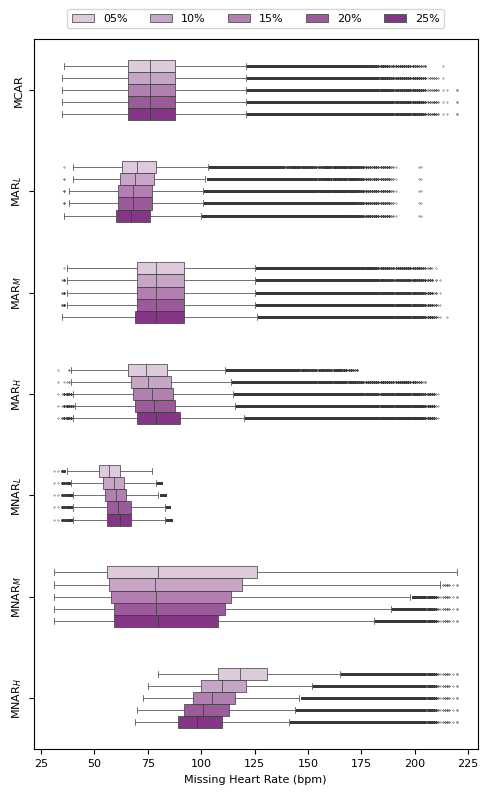

: 

In [ ]:
pal = sns.light_palette("purple", n_colors=7)
pal = pal[1:7]

plt.figure(figsize=(5, 8))  # altura > largura
ax = sns.boxplot(
    data=df_all,  # apenas 15%
    x='target', 
    y='mechanism',  # invertido
    hue='miss',
    palette=pal,
    fliersize=0.3,
    linewidth=0.5,
    width=0.6
)
labels = [t.get_text() for t in ax.get_yticklabels()]
labels_fmt = [r'{}$_{{{}}}$'.format(x.split('_')[0], x.split('_')[1].upper()) if '_' in x else x for x in labels]
ax.set_yticklabels(labels_fmt, fontsize=8, rotation=90, va='center')

plt.xlabel('Missing Heart Rate (bpm)', fontsize=8)
plt.ylabel('')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8, rotation=90, va = 'center')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=len(df_all['miss'].unique()), fontsize=8)

plt.tight_layout()
plt.savefig("Plots/missing_boxplot.png", dpi=300)
plt.show()

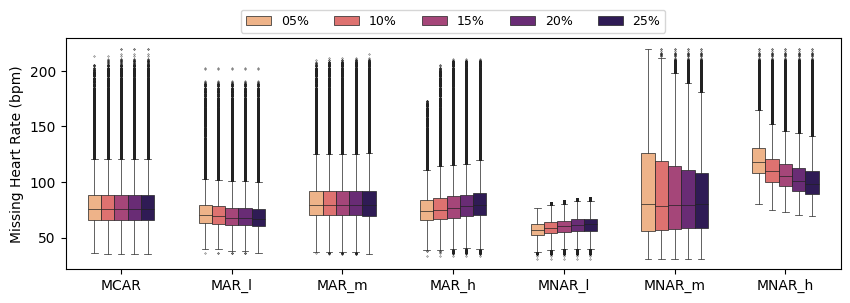

In [5]:
plt.figure(figsize=(10, 3))
sns.boxplot(data=df_all, x='mechanism', y='target', hue='miss', palette="magma_r", fliersize=0.3, linewidth=0.5, width=0.6)
plt.xlabel('')
plt.ylabel('Missing Heart Rate (bpm)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=len(df_all['miss'].unique()),fontsize=9)
plt.savefig(f"Plots/missing_boxplot.png",dpi=300)
plt.show()

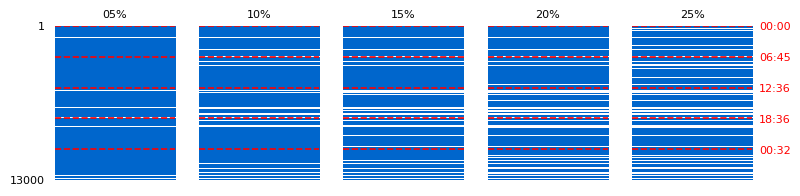

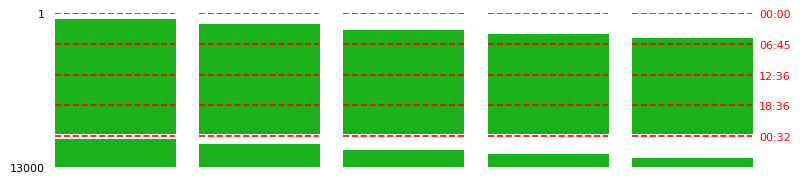

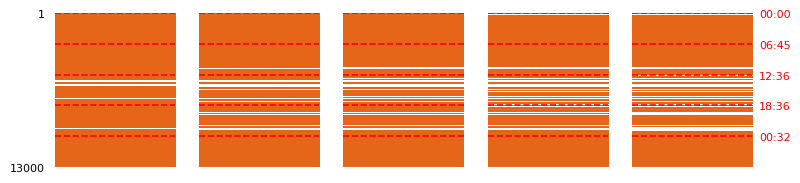

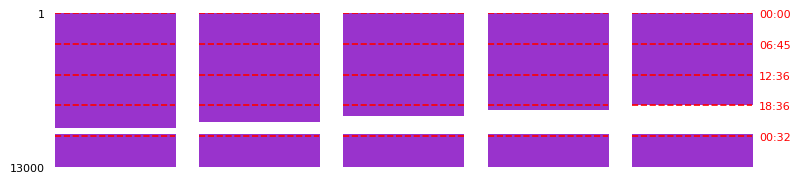

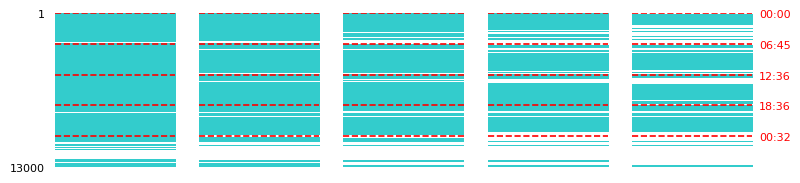

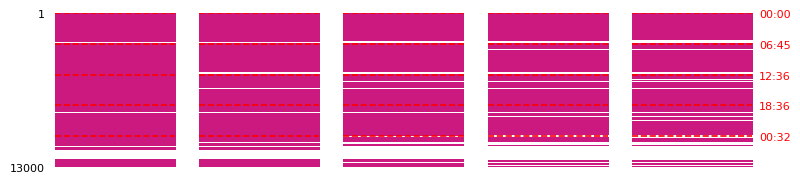

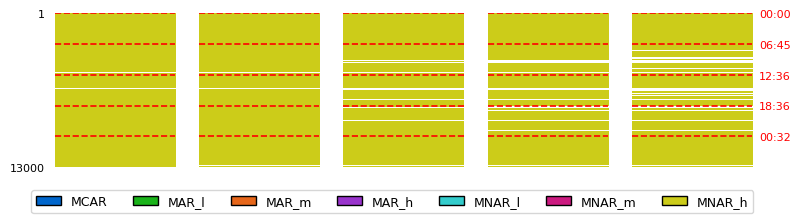

In [8]:
from matplotlib.patches import Patch

df_mec = {}
for mec in ['MCAR','MAR_l', 'MAR_m', 'MAR_h', 'MNAR_l', 'MNAR_m', 'MNAR_h']:
    df_mec[mec] = [pd.read_csv(os.path.join(f'COVID-19-Wearables-Missing/{mec}/AAXAA7Z/1', f)) 
                   for f in sorted(os.listdir(f'COVID-19-Wearables-Missing/{mec}/AAXAA7Z/1')) if f.endswith('.csv')]

color_map = {
    'MCAR': (0, 0.4, 0.8),      # blue
    'MAR_l': (0.1, 0.7, 0.1),   # green
    'MAR_m': (0.9, 0.4, 0.1), # orange
    'MAR_h': (0.6, 0.2, 0.8),   # purple
    'MNAR_l': (0.2, 0.8, 0.8),  # cyan
    'MNAR_m': (0.8, 0.1, 0.5),  # pink
    'MNAR_h': (0.8, 0.8, 0.1),  # yellow
}

N = 13000
D = 5
y_ticks = []

for j, (mec, dfs) in enumerate(df_mec.items()):
    fig, axes = plt.subplots(1, len(dfs), figsize=(9, 2))
    for i, (df, ax) in enumerate(zip(dfs, axes)):
        msno.matrix(df[['heartrate']][:N], sparkline=False, ax=ax, fontsize=7,labels="", color=color_map[mec])
        if j == 0:
            ax.set_title(f"{['05','10','15','20','25'][i]}%", fontsize=8)
        if i == 0:
            ax.get_yaxis().set_visible(True)
        elif i == 4:
            ticks = df.head(N).index[::int(N/D)]
            labels = pd.to_datetime(df["datetime"].head(N).iloc[::int(N/D)]).dt.strftime('%H:%M')
            ax.yaxis.tick_right()
            ax.tick_params(axis='y', pad=5, length=0)
            ax.set_yticks(ticks)
            ax.set_yticklabels(labels, fontsize=8, color='red')
            time_ticks = ticks
        else:
            ax.get_yaxis().set_visible(False)
    
    for y in time_ticks:
        for ax in axes:
            ax.axhline(y, color='red', linestyle='--', linewidth=1.2, alpha=1, zorder=10)

    if j == len(df_mec) - 1:
        legend_elements = [Patch(facecolor=color_map[key], edgecolor='k', label=key) for key in color_map]
        fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=len(color_map), fontsize=9)

    fig.savefig(
        f"Plots/{mec}_missing_matrix.png",
        dpi=300, bbox_inches='tight'
    )

In [9]:
from PIL import Image
import glob

# Get all PNG files in the directory, sorted by mechanism order
mechanism_order = ['MCAR', 'MAR_l','MAR_m', 'MAR_h', 'MNAR_l', 'MNAR_m', 'MNAR_h']
img_paths = [f"Plots/{mec}_missing_matrix.png" for mec in mechanism_order]

# Open images
images = [Image.open(p) for p in img_paths]

# Calculate max width and total height for vertical concatenation
max_width = max(img.width for img in images)
total_height = sum(img.height for img in images)

# Create a new blank image for vertical stacking
combined_img = Image.new('RGB', (max_width, total_height), (255, 255, 255))

# Paste images one below the other
y_offset = 0
for img in images:
    combined_img.paste(img, (0, y_offset))
    y_offset += img.height

# Save the combined image
combined_img.save('Plots/missing_matrix_hros.png')